# Set up
**Import libraries**

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

**Load and merge datasets**

In [2]:

df = pd.read_csv("../data/bunny.csv")
habitat = pd.read_csv("../data/habitats.csv")

df = df.merge(habitat, how="left", on=["decimalLatitude", "decimalLongitude"])

C:\Users\sanne\AppData\Local\Temp\ipykernel_6776\1069266697.py:1: DtypeWarning: Columns (0: Oryctolagus cuniculus) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/bunny.csv")


---

## 1. Business Understanding

**Business Objective** 

* The objective of this project is to develop a predictive model for observations of Oryctolagus cuniculus using environmental and temporal factors such as habitat type, seasonality, temperature, precipitation, and geographic location.
The model aims to predict where and when rabbit observations are most likely to occur, helping improve biodiversity monitoring, ecological research, and wildlife management decisions.

**Business Success Criteria**

* The model will be considered successful if it:
Achieves at least 75% prediction accuracy on unseen observation data
Correctly identifies seasonal and habitat-related patterns in rabbit observations
Maintains stable performance across different geographic regions and weather conditions

**Data Mining Goals**

* Develop a classification model that predicts the likelihood of observing Oryctolagus cuniculus using environmental variables such as habitat type, seasonality, temperature, precipitation, and geographic location.

**Data Mining Success Criteria**

* Our model should achieve at least:
75% accuracy in predicting observations of Oryctolagus cuniculus
70% precision when identifying locations and time periods with rabbit observations
75% recall in detecting actual rabbit observation occurrences based on habitat, seasonal, and weather-related variables
The model should also maintain stable predictive performance across different regions and seasons.

---

## 2. Data understanding

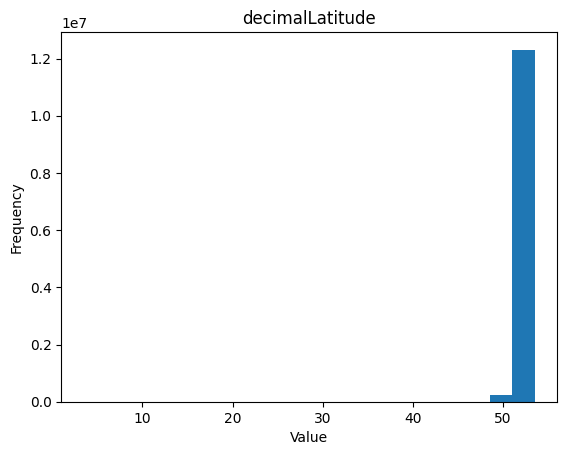

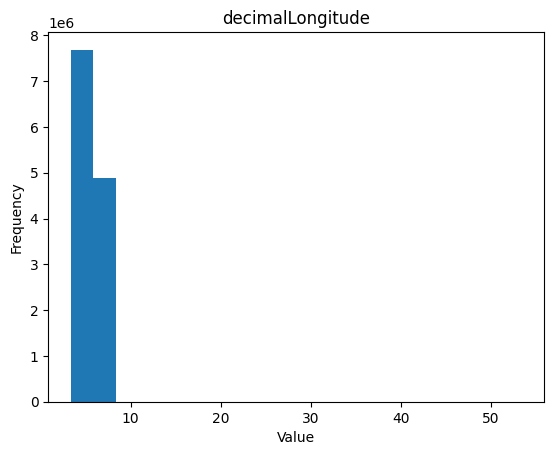

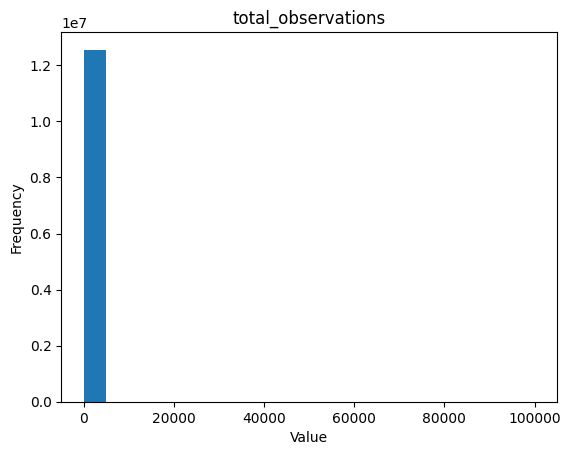

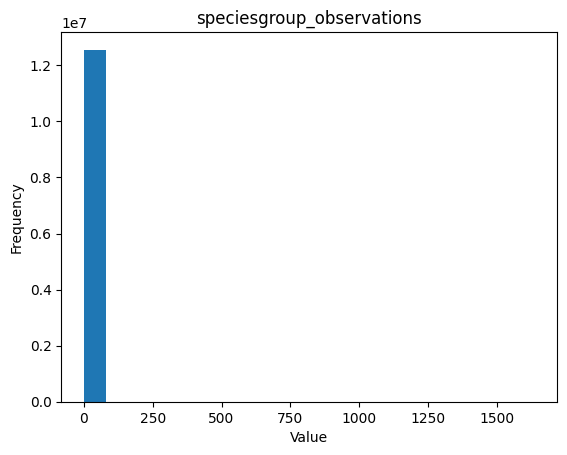

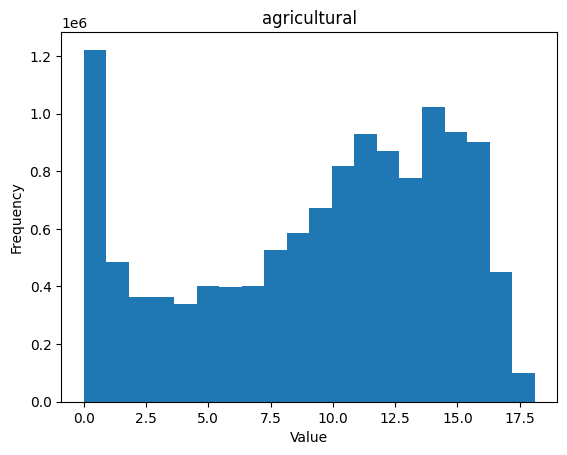

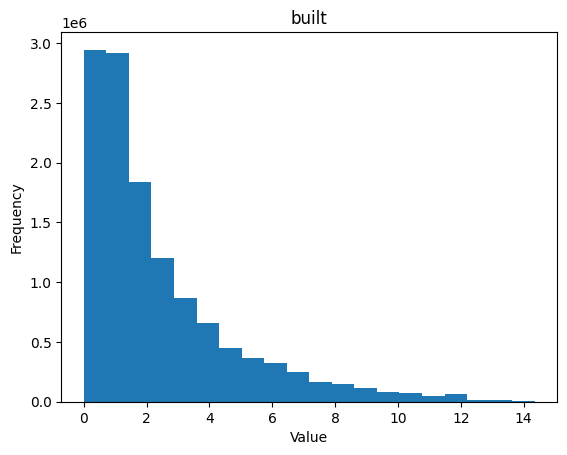

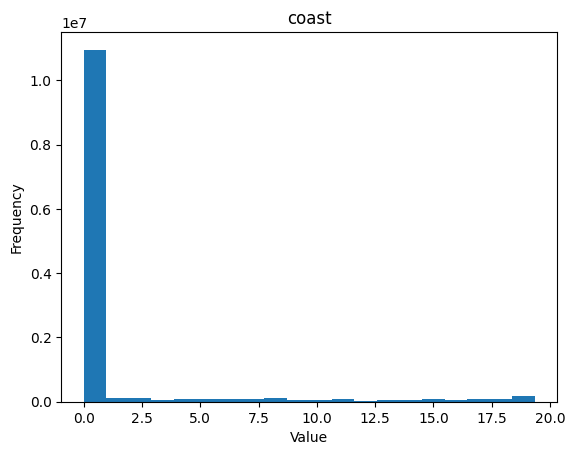

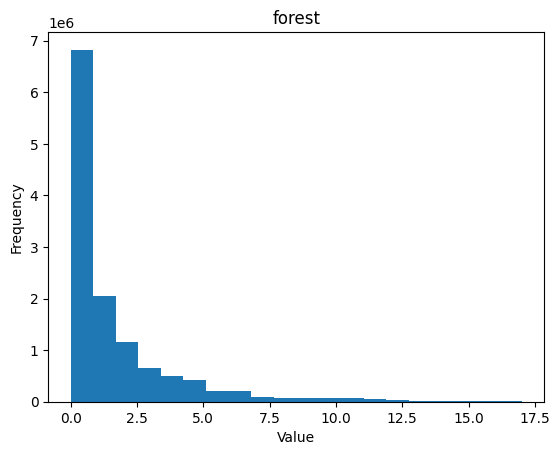

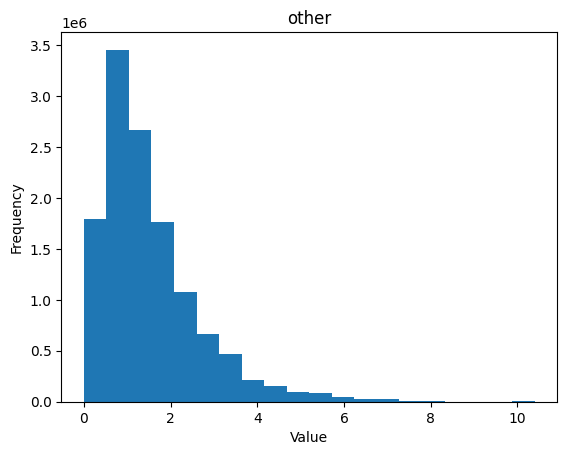

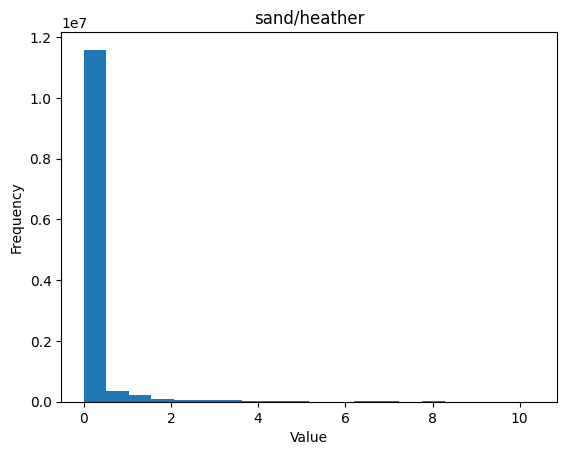

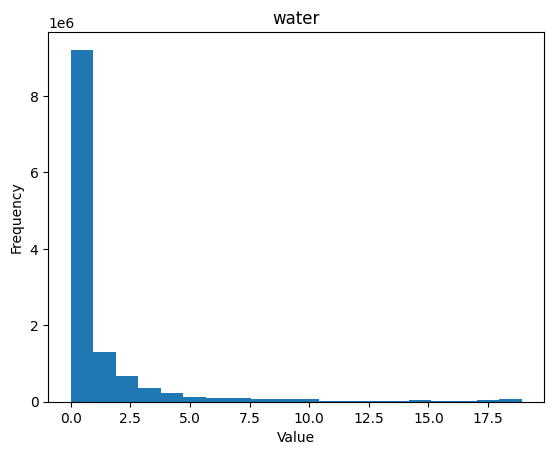

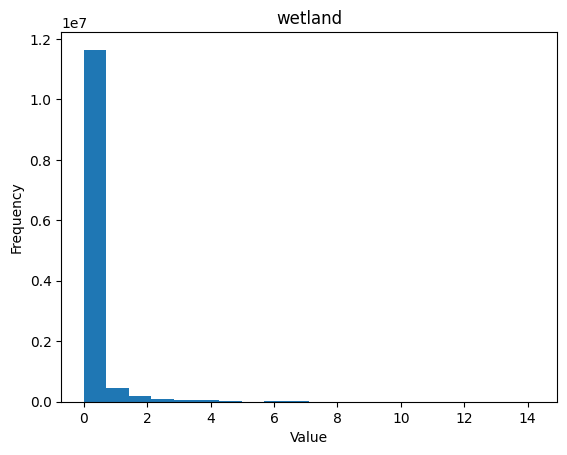

In [3]:
for col in df.describe().columns:
    plt.figure()
    plt.hist(df[col], bins=20)
    plt.title(col)
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.show()

In [4]:
df.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Oryctolagus cuniculus,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat
0,50.75,5.65,2010-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
1,50.75,5.65,2010-01-02,26.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
2,50.75,5.65,2010-01-03,3.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
3,50.75,5.65,2010-01-04,0.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
4,50.75,5.65,2010-01-05,0.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 15 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  str    
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Oryctolagus cuniculus      object 
 6   agricultural               float64
 7   built                      float64
 8   coast                      float64
 9   forest                     float64
 10  other                      float64
 11  sand/heather               float64
 12  water                      float64
 13  wetland                    float64
 14  main_habitat               str    
dtypes: float64(11), int64(1), object(1), str(2)
memory usage: 1.4+ GB


In [6]:
df.describe()

,decimalLatitude,decimalLongitude,total_observations,speciesgroup_observations,agricultural,built,coast,forest,other,sand/heather,water,wetland
count,1.255879e+07,1.255879e+07,1.255878e+07,1.255879e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07
mean,5.222995e+01,5.532896e+00,8.136004e+00,2.212651e-01,9.452277e+00,2.404833e+00,1.302932e+00,1.621184e+00,1.501486e+00,1.881532e-01,1.245543e+00,2.249716e-01
std,6.647267e-01,8.779710e-01,6.264853e+01,2.511784e+00,5.147907e+00,2.419758e+00,3.970215e+00,2.385737e+00,1.167872e+00,7.709894e-01,2.688194e+00,7.063523e-01
min,3.500000e+00,3.350000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.170000e+01,4.900000e+00,0.000000e+00,0.000000e+00,5.348400e+00,7.667000e-01,0.000000e+00,1.494000e-01,7.249000e-01,0.000000e+00,9.900000e-02,0.000000e+00
50%,5.220000e+01,5.650000e+00,1.000000e+00,0.000000e+00,1.056820e+01,1.559900e+00,0.000000e+00,7.092000e-01,1.199800e+00,0.000000e+00,3.102000e-01,1.820000e-02
75%,5.280000e+01,6.200000e+00,6.000000e+00,0.000000e+00,1.380080e+01,3.291600e+00,0.000000e+00,2.036400e+00,2.006500e+00,2.340000e-02,1.033000e+00,1.417000e-01
max,5.350000e+01,5.340000e+01,1.000400e+05,1.637000e+03,1.810460e+01,1.435380e+01,1.934870e+01,1.699850e+01,1.039830e+01,1.034430e+01,1.890870e+01,1.422410e+01


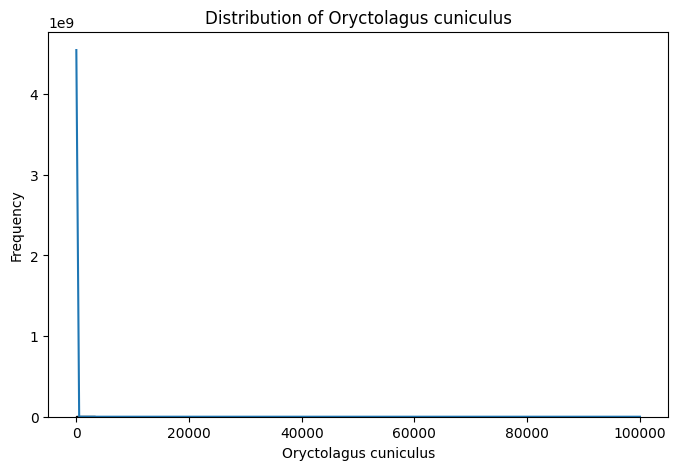

In [7]:
# CODE CELL: Generate visualizations (e.g., scatter plots, histograms)
plt.figure(figsize=(8,5))
sns.histplot(df["total_observations"], bins=30, kde=True)

plt.title("Distribution of Oryctolagus cuniculus")
plt.xlabel("Oryctolagus cuniculus")
plt.ylabel("Frequency")

plt.show()

In [8]:
df.isnull().sum()

decimalLatitude               0
decimalLongitude              0
eventDate                     0
total_observations            3
speciesgroup_observations     0
Oryctolagus cuniculus         0
agricultural                 30
built                        30
coast                        30
forest                       30
other                        30
sand/heather                 30
water                        30
wetland                      30
main_habitat                 30
dtype: int64

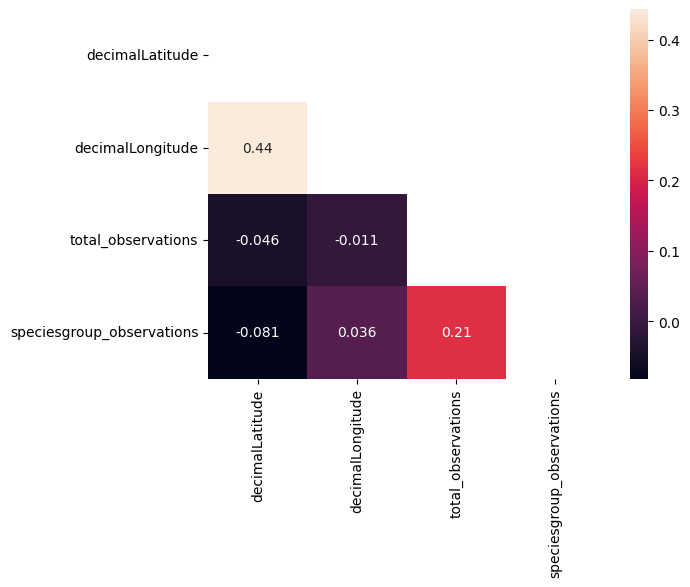

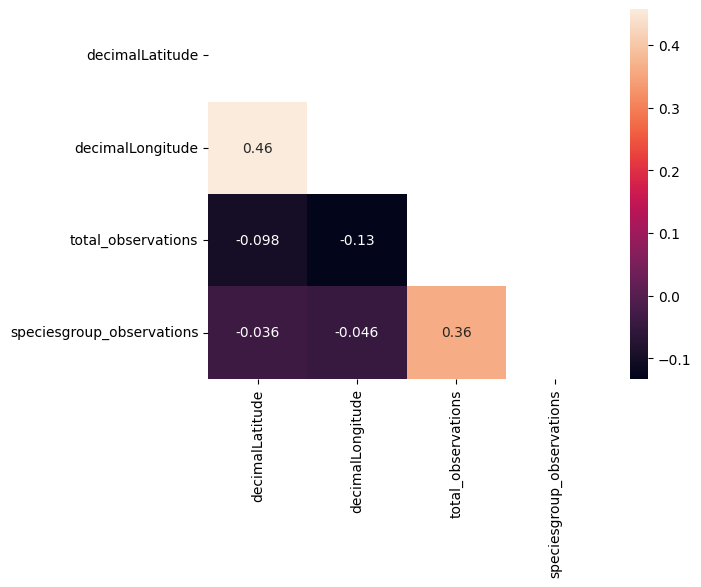

In [3]:
import seaborn as sns
import numpy as np
# Display only half of the correlation matrix
mask = np.triu(np.ones_like(df.corr(numeric_only=True, method='pearson'), dtype=bool))
sns.heatmap(df.corr(numeric_only=True, method='pearson'), annot=True, mask=mask)
plt.show()

sns.heatmap(df.corr(numeric_only=True, method='spearman'), annot=True, mask=mask)
plt.show()